#model loading

In [2]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")



from langchain.chat_models import init_chat_model
import os



llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)


llm = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)

Blue
Blue


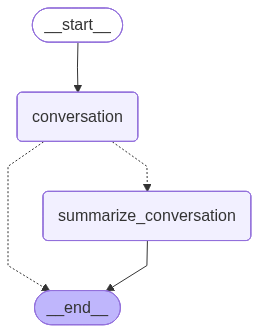

In [3]:
from IPython.display import Image, display
from typing import Literal

# from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# LLM
# model = ChatOpenAI(model="gpt-4o", temperature=0) 
model = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

# State 
class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State)-> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content="Hey Lance! 👋 Great to meet you. How's your day going? I'm here if you want to chat, ask questions, or just bounce ideas around—whatever you need! 😊", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:16:16.57373938Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1228921662, 'load_duration': None, 'prompt_eval_count': 22, 'prompt_eval_duration': None, 'eval_count': 184, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e91f3-8883-7112-beb7-1a4b74573cb5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 184, 'total_tokens': 206})}}


In [8]:
print(chunk['conversation']['messages'])

content="Hey Lance! 👋 Great to meet you. How's your day going? I'm here if you want to chat, ask questions, or just bounce ideas around—whatever you need! 😊" additional_kwargs={} response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:16:16.57373938Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1228921662, 'load_duration': None, 'prompt_eval_count': 22, 'prompt_eval_duration': None, 'eval_count': 184, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'} id='lc_run--019e91f3-8883-7112-beb7-1a4b74573cb5-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 22, 'output_tokens': 184, 'total_tokens': 206}


In [11]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)


================================ Human Message =================================

hi! I'm Lance
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hey Lance! 👋 Great to meet you — thanks for saying hi! How's your day going? I'm here if you want to chat, ask questions, or just bounce ideas around. What's on your mind? 😊
---------------------------------------------------------------------------
================================== Ai Message ==================================

Hey Lance again! ✨ Still here and ready whenever you are—whether you wanna chat, ask something random, or just say hi. No pressure at all. How’s your day treating you so far? 😊


In [14]:
event['messages']

[HumanMessage(content="hi! I'm Lance", additional_kwargs={}, response_metadata={}, id='d293ed0f-1b2b-430b-8756-f7e1d665be24'),
 AIMessage(content="Hey Lance! 👋 Great to meet you — thanks for saying hi! How's your day going? I'm here if you want to chat, ask questions, or just bounce ideas around. What's on your mind? 😊", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:18:43.384025438Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3122651308, 'load_duration': None, 'prompt_eval_count': 22, 'prompt_eval_duration': None, 'eval_count': 203, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e91f5-c0b5-73f3-9a0c-629dd66ea4bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 203, 'total_tokens': 225})]

# break points

In [18]:
# from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
# llm = ChatOpenAI(model="gpt-4o")
llm = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

llm_with_tools = llm.bind_tools(tools)

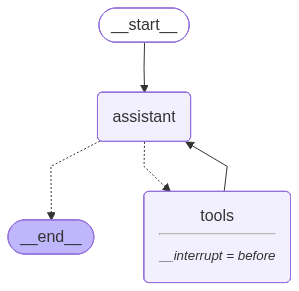

In [20]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [21]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (a2be7e3c-d58b-42a3-9c07-c210ddb4ab30)
 Call ID: a2be7e3c-d58b-42a3-9c07-c210ddb4ab30
  Args:
    a: 2
    b: 3


In [22]:
event

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='65695764-97c5-40fc-8d68-b97ff18b459d'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:26:45.106286248Z', 'done': True, 'done_reason': 'stop', 'total_duration': 447781588, 'load_duration': None, 'prompt_eval_count': 525, 'prompt_eval_duration': None, 'eval_count': 69, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e91fd-2472-7c30-9233-6d39ad812d9d-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'a2be7e3c-d58b-42a3-9c07-c210ddb4ab30', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 525, 'output_tokens': 69, 'total_tokens': 594})]}

In [23]:
state = graph.get_state(thread)
state.next

('tools',)

In [24]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='65695764-97c5-40fc-8d68-b97ff18b459d'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:26:45.106286248Z', 'done': True, 'done_reason': 'stop', 'total_duration': 447781588, 'load_duration': None, 'prompt_eval_count': 525, 'prompt_eval_duration': None, 'eval_count': 69, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e91fd-2472-7c30-9233-6d39ad812d9d-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'a2be7e3c-d58b-42a3-9c07-c210ddb4ab30', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 525, 'output_tokens': 69, 'total_tokens': 594})]}, next=('tools',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff8c-4dcd-629c-8001-753ebeb

In [25]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (a2be7e3c-d58b-42a3-9c07-c210ddb4ab30)
 Call ID: a2be7e3c-d58b-42a3-9c07-c210ddb4ab30
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The product of 2 and 3 is **6**.


In [26]:
event

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='65695764-97c5-40fc-8d68-b97ff18b459d'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:26:45.106286248Z', 'done': True, 'done_reason': 'stop', 'total_duration': 447781588, 'load_duration': None, 'prompt_eval_count': 525, 'prompt_eval_duration': None, 'eval_count': 69, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e91fd-2472-7c30-9233-6d39ad812d9d-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'a2be7e3c-d58b-42a3-9c07-c210ddb4ab30', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 525, 'output_tokens': 69, 'total_tokens': 594}),
  ToolMessage(content='6', name='multiply', id='cce0d072-6dff-480e-ae4f-fb6c3fed3c16', tool_call_id='a2be7e3c-d58b-42a3-9c07-c210ddb4ab30'),
  AIMessag

In [ ]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "2"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":
    
    # If approved, continue the graph execution
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()
        
else:
    print("Operation cancelled by user.")

In [27]:
# from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
# llm = ChatOpenAI(model="gpt-4o")
llm = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

llm_with_tools = llm.bind_tools(tools)

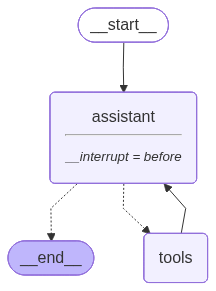

In [28]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [29]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "11"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [30]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620')]}, next=('assistant',), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aacb-6cc3-8000-6c591342b7d6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-04T09:43:07.700960+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aa23-6055-bfff-f557d7067dd0'}}, tasks=(PregelTask(id='d4588b12-32ce-1d0d-4a6f-775b227ceb05', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [ ]:
StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620')]}, next=('assistant',), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aacb-6cc3-8000-6c591342b7d6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-04T09:43:07.700960+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aa23-6055-bfff-f557d7067dd0'}}, tasks=(PregelTask(id='d4588b12-32ce-1d0d-4a6f-775b227ceb05', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [31]:
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
)

{'configurable': {'thread_id': '11',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15ff9f-ee7e-6dc8-8001-87bb49d60878'}}

In [32]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196')]}, next=('assistant',), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9f-ee7e-6dc8-8001-87bb49d60878'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-04T09:44:35.330400+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aacb-6cc3-8000-6c591342b7d6'}}, tasks=(PregelTask(id='6948650e-7726-dab3-5fea-55513d8dedf2', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [ ]:
StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196')]}, next=('assistant',), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9f-ee7e-6dc8-8001-87bb49d60878'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-04T09:44:35.330400+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aacb-6cc3-8000-6c591342b7d6'}}, tasks=(PregelTask(id='6948650e-7726-dab3-5fea-55513d8dedf2', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

Now, we can directly apply a state update.

Remember, updates to the `messages` key will use the `add_messages` reducer:
 
* If we want to over-write the existing message, we can supply the message `id`.
* If we simply want to append to our list of messages, then we can pass a message without an `id` specified, as shown below.

In [33]:
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, actually multiply 3 and 3!


In [34]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 3 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (1f9eecbf-93df-4986-81eb-dcd1f6ee49a1)
 Call ID: 1f9eecbf-93df-4986-81eb-dcd1f6ee49a1
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [35]:
event

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'),
  HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:39:01.03180526Z', 'done': True, 'done_reason': 'stop', 'total_duration': 638362525, 'load_duration': None, 'prompt_eval_count': 540, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9208-5ff8-7ab3-a37d-f06905be3d38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': '1f9eecbf-93df-4986-81eb-dcd1f6ee49a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 540, 'output_tokens': 97, 'total_tokens': 637}),
  ToolM

In [36]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

9


In [37]:
event

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'),
  HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:39:01.03180526Z', 'done': True, 'done_reason': 'stop', 'total_duration': 638362525, 'load_duration': None, 'prompt_eval_count': 540, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9208-5ff8-7ab3-a37d-f06905be3d38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': '1f9eecbf-93df-4986-81eb-dcd1f6ee49a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 540, 'output_tokens': 97, 'total_tokens': 637}),
  ToolM

# daynamic breakpoint

In [39]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:39:01.03180526Z', 'done': True, 'done_reason': 'stop', 'total_duration': 638362525, 'load_duration': None, 'prompt_eval_count': 540, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9208-5ff8-7ab3-a37d-f06905be3d38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': '1f9eecbf-93df-4986-81eb-dcd1f6ee49a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 540, 'output_tokens': 97, 'total_tokens

In [40]:
print(state)

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:39:01.03180526Z', 'done': True, 'done_reason': 'stop', 'total_duration': 638362525, 'load_duration': None, 'prompt_eval_count': 540, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9208-5ff8-7ab3-a37d-f06905be3d38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': '1f9eecbf-93df-4986-81eb-dcd1f6ee49a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 540, 'output_tokens': 97, 'total_tokens

In [ ]:
StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:39:01.03180526Z', 'done': True, 'done_reason': 'stop', 'total_duration': 638362525, 'load_duration': None, 'prompt_eval_count': 540, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9208-5ff8-7ab3-a37d-f06905be3d38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': '1f9eecbf-93df-4986-81eb-dcd1f6ee49a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 540, 'output_tokens': 97, 'total_tokens': 637}), ToolMessage(content='9', name='multiply', id='76f2a367-6215-40c9-a0c7-b60f2d1b203e', tool_call_id='1f9eecbf-93df-4986-81eb-dcd1f6ee49a1'), AIMessage(content='9', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:40:40.265175383Z', 'done': True, 'done_reason': 'stop', 'total_duration': 470361322, 'load_duration': None, 'prompt_eval_count': 591, 'prompt_eval_duration': None, 'eval_count': 51, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9209-e367-70a3-aace-28838e7e8c6c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 591, 'output_tokens': 51, 'total_tokens': 642})]}, next=(), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ffab-6aa1-61f3-8004-de95e1e41dd4'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-06-04T09:49:43.625777+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ffa7-b855-65e7-8003-4c9cacf23e0b'}}, tasks=(), interrupts=())

In [41]:
all_states = [s for s in graph.get_state_history(thread)]

In [42]:
all_states

[StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='1ca80529-62e8-4c2a-bc5f-8209ca5cf196'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T09:39:01.03180526Z', 'done': True, 'done_reason': 'stop', 'total_duration': 638362525, 'load_duration': None, 'prompt_eval_count': 540, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e9208-5ff8-7ab3-a37d-f06905be3d38-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': '1f9eecbf-93df-4986-81eb-dcd1f6ee49a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 540, 'output_tokens': 97, 'total_token

In [43]:
to_replay = all_states[-2]

In [44]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620')]}, next=('assistant',), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aacb-6cc3-8000-6c591342b7d6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-04T09:43:07.700960+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f15ff9c-aa23-6055-bfff-f557d7067dd0'}}, tasks=(PregelTask(id='d4588b12-32ce-1d0d-4a6f-775b227ceb05', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [45]:
to_replay.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='95f8c069-f71c-49e6-9610-dd49b4efa620')]}

In [46]:
to_replay.next

('assistant',)

In [47]:
to_replay.config

{'configurable': {'thread_id': '11',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15ff9c-aacb-6cc3-8000-6c591342b7d6'}}

In [48]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (8ac20421-a45f-4a93-9f15-9abff59a1b9f)
 Call ID: 8ac20421-a45f-4a93-9f15-9abff59a1b9f
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


## memoey

In [51]:
import uuid
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver
in_memory_store = InMemoryStore()

When storing objects (e.g., memories) in the [Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore), we provide:

- The `namespace` for the object, a tuple (similar to directories)
- the object `key` (similar to filenames)
- the object `value` (similar to file contents)

We use the [put](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.put) method to save an object to the store by `namespace` and `key`.



In [53]:
# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())

# The value needs to be a dictionary  
value = {"food_preference" : "I like pizza"}

# Save the memory
in_memory_store.put(namespace_for_memory, key, value)

In [54]:
# Search 
memories = in_memory_store.search(namespace_for_memory)
type(memories)

list

In [55]:
memories

[Item(namespace=['1', 'memories'], key='8e53090b-5802-44a3-9776-bdf4e96b533b', value={'food_preference': 'I like pizza'}, created_at='2026-06-04T10:03:33.884931+00:00', updated_at='2026-06-04T10:03:33.884931+00:00', score=None),
 Item(namespace=['1', 'memories'], key='95904335-554d-48f4-b16a-f45f47521b2f', value={'food_preference': 'I like pizza'}, created_at='2026-06-04T10:03:52.082145+00:00', updated_at='2026-06-04T10:03:52.082145+00:00', score=None)]

In [56]:
# Metatdata 
memories[0].dict()

{'namespace': ['1', 'memories'],
 'key': '8e53090b-5802-44a3-9776-bdf4e96b533b',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-06-04T10:03:33.884931+00:00',
 'updated_at': '2026-06-04T10:03:33.884931+00:00',
 'score': None}

In [57]:
# Get the memory by namespace and key
memory = in_memory_store.get(namespace_for_memory, key)
memory.dict()

{'namespace': ['1', 'memories'],
 'key': '95904335-554d-48f4-b16a-f45f47521b2f',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-06-04T10:03:52.082145+00:00',
 'updated_at': '2026-06-04T10:03:52.082145+00:00'}

In [58]:

# The value needs to be a dictionary  
value = {"work_preferences" : "work from home"}

# Save the memory
in_memory_store.put(namespace_for_memory, key, value)

In [59]:
# Search 
memories = in_memory_store.search(namespace_for_memory)
type(memories)

list

In [60]:
memories

[Item(namespace=['1', 'memories'], key='8e53090b-5802-44a3-9776-bdf4e96b533b', value={'food_preference': 'I like pizza'}, created_at='2026-06-04T10:03:33.884931+00:00', updated_at='2026-06-04T10:03:33.884931+00:00', score=None),
 Item(namespace=['1', 'memories'], key='95904335-554d-48f4-b16a-f45f47521b2f', value={'work_preferences': 'work from home'}, created_at='2026-06-04T10:07:01.547520+00:00', updated_at='2026-06-04T10:07:01.547520+00:00', score=None)]

In [61]:
memories.value.get('memory')

AttributeError: 'list' object has no attribute 'value'

In [ ]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user. 
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """"You are collecting information about the user to personalize your responses.

CURRENT USER  :
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
   - Personal details (name, location)
   - Preferences (likes, dislikes)
   - Interests and hobbies
   - Past experiences
   - Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    # Extract the actual memory content if it exists and add a prefix
    if existing_memory:
        # Value is a dictionary with a memory key
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in the system prompt
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    
    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and save a memory to the store."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve existing memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
        
    # Extract the memory
    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in the system prompt
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'])

    # Overwrite the existing memory in the store 
    key = "user_memory"

    # Write value as a dictionary with a memory key
    store.put(namespace, key, {"memory": new_memory.content})

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))